In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import warnings, os, gc, re
import matplotlib.pyplot as plt
import swifter
import psutil

# from plotnine import ggplot, aes, geom_line
from plotnine import *
# import pygal as pg
%matplotlib inline

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [2]:
# sample read
data_source = (
    "https://gist.githubusercontent.com/"
    "notionparallax/7ada7b733216001962dbaa789e246a67/raw/"
    "6d306b5d928b04a5a2395469694acdd8af3cbafb/example.csv"
)

df = (
    pd.read_csv(data_source, index_col=0)
    .assign(ed_name=lambda x: x["ed_name"].str.extract(r"(\d+)").astype(int))
    .value_counts(["ed_name", "source"])
    .groupby("ed_name")
    .rank("first", ascending=False)
    .rename("rank")
    .sort_index()
    .reset_index()
    .query("ed_name < 17")
)

In [4]:
df.head(20)

,ed_name,source,rank
0,1,groene.nl,2.0000
1,1,lithub,7.0000
2,1,newyorker,1.0000
3,1,thecut,6.0000
4,1,theguardian,5.0000
5,1,therumpus.net,4.0000
6,1,volkskrant.nl,3.0000
7,2,aeon.co,2.0000
8,2,allaboutcircuits,19.0000
9,2,anxeducation.tumblr,18.0000


In [10]:
xls = pd.ExcelFile('ranking icd.xlsx')
df_icd_cnt = pd.read_excel(xls, 'icd - counts')
df_proc_cnt = pd.read_excel(xls, 'proc - counts')
df_icd_sum = pd.read_excel(xls, 'icd - sum')
df_proc_sum = pd.read_excel(xls, 'proc - sum')

In [35]:
n_top_ranked = 10
top_sources = df_icd_cnt[df_icd_cnt['year'] == df_icd_cnt['year'].max()].nsmallest(n_top_ranked, 'rank')
top_sources.head(20)

,rank,year,code
175,0,2020,J18.92
176,1,2020,A09.9
177,2,2020,N39.0
178,3,2020,A97.1
179,4,2020,K29.1
180,5,2020,I10.1
181,6,2020,I10.9
182,7,2020,P36.9
183,8,2020,J45.90
184,9,2020,A97.0


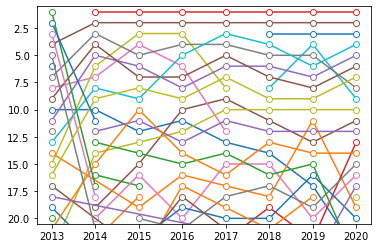

In [34]:
for i, j in df_icd_cnt.groupby('code'):
    plt.plot('year', 'rank', 'o-' , data=j, mfc='w')
plt.ylim(0.5, 0.5 + n_top_ranked)
plt.gca().invert_yaxis()

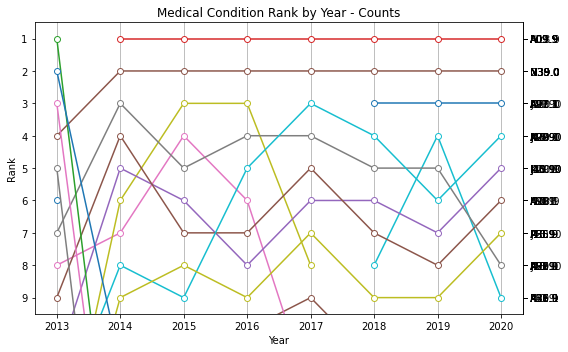

In [55]:
n_top_ranked = 9

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedFormatter, FixedLocator

fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=dict(ylim=(0.5, 0.5 + n_top_ranked)))

ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))

yax2 = ax.secondary_yaxis('right')
yax2.yaxis.set_major_locator(FixedLocator(df_icd_cnt['rank'].to_list()))
yax2.yaxis.set_major_formatter(FixedFormatter(df_icd_cnt['code'].to_list()))
# yax2.yaxis.set_major_formatter(FixedFormatter(df_icd_cnt['code'].head(11).to_list()))


for i, j in df_icd_cnt.groupby('code'):
    ax.plot('year', 'rank', 'o-' , data=j, mfc='w')
    
ax.invert_yaxis()
ax.set(xlabel='Year', ylabel='Rank', title='Medical Condition Rank by Year - Counts')
ax.grid(axis='x')
plt.tight_layout()